# 01 · Supervision and acquisition-representation audit
## RSNA Knee Abnormality Detection · Milestone 01

**Research question:** What trustworthy supervision and image-acquisition coverage do we actually have before selecting expensive representations?

This is a CPU metadata audit, **not a predictive feature-ablation study**. The notebook constructs fixed acquisition descriptors, preserves unknown clinical labels, and profiles reports without displaying their text. It does not download MRI images, extract clinical report labels, fit an encoder, call an LLM, use cloud APIs or submit predictions.

**Prerequisites:** matching passing tests; completed notebook 00; the five CSVs under `data/raw/metadata/`. Select **RSNA Knee - audit** and **Kernel → Restart Kernel and Run All Cells**. Runtime guards apply to each worker invocation; saved completed stages are verified by checksums.

The first invocation deliberately pauses after the schema stage. The second must reuse it and complete the remaining stages. This tests **graceful checkpoint resumption**, not every possible crash scenario.

Sources and hypotheses: [research protocol](../docs/RESEARCH_PROTOCOL.md), [source register](../docs/SOURCES.md), [feature registry](../configs/feature_registry.csv). Reports are training-only; missing labels are not negative. No expert-outcome prevalence plots or per-study report examples appear here.


In [1]:
from pathlib import Path
import json
import sys
ROOT = Path.home() / "rsna-knee-abnormality-detection"
assert (ROOT / "configs/milestone01.json").is_file(), "Open the installed project, not a loose notebook."
assert Path(sys.prefix).resolve() == (ROOT / ".venv").resolve(), "Select kernel: RSNA Knee - audit"
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, Markdown
from rsna_knee.runtime import require_tests
pio.renderers.default = "plotly_mimetype"
TESTS = require_tests(ROOT)
print(f"Matching synthetic test receipt: {TESTS['tests']} tests; failures={TESTS['failures']}; errors={TESTS['errors']}")
print("No project model has been fitted by this notebook.")


Matching synthetic test receipt: 123 tests; failures=0; errors=0
No project model has been fitted by this notebook.


In [2]:
from rsna_knee.runtime import run_bounded
CONFIG = json.loads((ROOT / "configs/milestone01.json").read_text())
command = [sys.executable, "scripts/audit_metadata.py"]
run_bounded(command + ["--stop-after", "schema"], ROOT,
    seconds=CONFIG["worker_hard_seconds"], rss_gib=CONFIG["worker_rss_gib"])
PAUSE = json.loads((ROOT / "artifacts/m01_pause_receipt.json").read_text())
assert PAUSE["status"] == "paused_as_requested" and PAUSE["stage"] == "schema"
print("Deliberate stage-boundary pause recorded. The next cell resumes from this evidence.")


{"utc": "2026-09-13T23:17:13.864253+00:00", "stage": "load", "event": "reading_five_csvs", "completed": 0, "total": 5, "total_elapsed_s": 0.0, "stage_elapsed_s": 0.0, "rss_gib": 0.071}
{"utc": "2026-09-13T23:17:14.154969+00:00", "stage": "load", "event": "schema_and_joins_checked", "completed": 5, "total": 5, "total_elapsed_s": 0.291, "stage_elapsed_s": 0.291, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:14.155277+00:00", "stage": "schema", "event": "computed", "completed": 0, "total": 1, "total_elapsed_s": 0.291, "stage_elapsed_s": 0.0, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:14.168174+00:00", "stage": "schema", "event": "stage_complete", "completed": 1, "total": 1, "total_elapsed_s": 0.304, "stage_elapsed_s": 0.013, "rss_gib": 0.088}
{
  "utc": "2026-09-13T23:17:14.168254+00:00",
  "status": "paused_as_requested",
  "key": "ea40bda00eb65237168de9bc64789d850e7cc72cf14df8d9af948694d87bc22e",
  "stage": "schema",
  "stages": {
    "schema": "computed"
  }
}
Deliberate stage-boundary 

In [3]:
run_bounded(command, ROOT, seconds=CONFIG["worker_hard_seconds"], rss_gib=CONFIG["worker_rss_gib"])
LATEST = json.loads((ROOT / "artifacts/m01_latest.json").read_text())
assert LATEST["status"] == "complete" and LATEST["key"] == PAUSE["key"]
assert LATEST["stages"]["schema"] == "reused_verified", "Schema was not demonstrably reused."
assert LATEST["raw_inputs_unchanged"] and LATEST["model_fits"] == 0
RUN = ROOT / LATEST["run_directory"]
SCHEMA = json.loads((RUN / "schema_summary.json").read_text())
SUPERVISION = json.loads((RUN / "supervision_summary.json").read_text())
REPRESENTATION = json.loads((RUN / "representation_summary.json").read_text())
print(json.dumps({"schema": SCHEMA, "supervision": SUPERVISION, "representation": REPRESENTATION}, indent=2))


{"utc": "2026-09-13T23:17:14.679239+00:00", "stage": "load", "event": "reading_five_csvs", "completed": 0, "total": 5, "total_elapsed_s": 0.0, "stage_elapsed_s": 0.0, "rss_gib": 0.071}
{"utc": "2026-09-13T23:17:14.978524+00:00", "stage": "load", "event": "schema_and_joins_checked", "completed": 5, "total": 5, "total_elapsed_s": 0.299, "stage_elapsed_s": 0.299, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:14.979190+00:00", "stage": "schema", "event": "reused_verified", "completed": 0, "total": 1, "total_elapsed_s": 0.3, "stage_elapsed_s": 0.0, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:14.979327+00:00", "stage": "schema", "event": "stage_complete", "completed": 1, "total": 1, "total_elapsed_s": 0.3, "stage_elapsed_s": 0.0, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:14.979548+00:00", "stage": "supervision", "event": "computed", "completed": 0, "total": 1, "total_elapsed_s": 0.3, "stage_elapsed_s": 0.0, "rss_gib": 0.088}
{"utc": "2026-09-13T23:17:15.011764+00:00", "stage": "supervision",

## 1 · Measured metadata, not assumed dataset counts
CSV parsers correctly handle embedded newlines in reports. File line counts are not study counts. These are the current local files, not a statement about every hidden evaluation study.


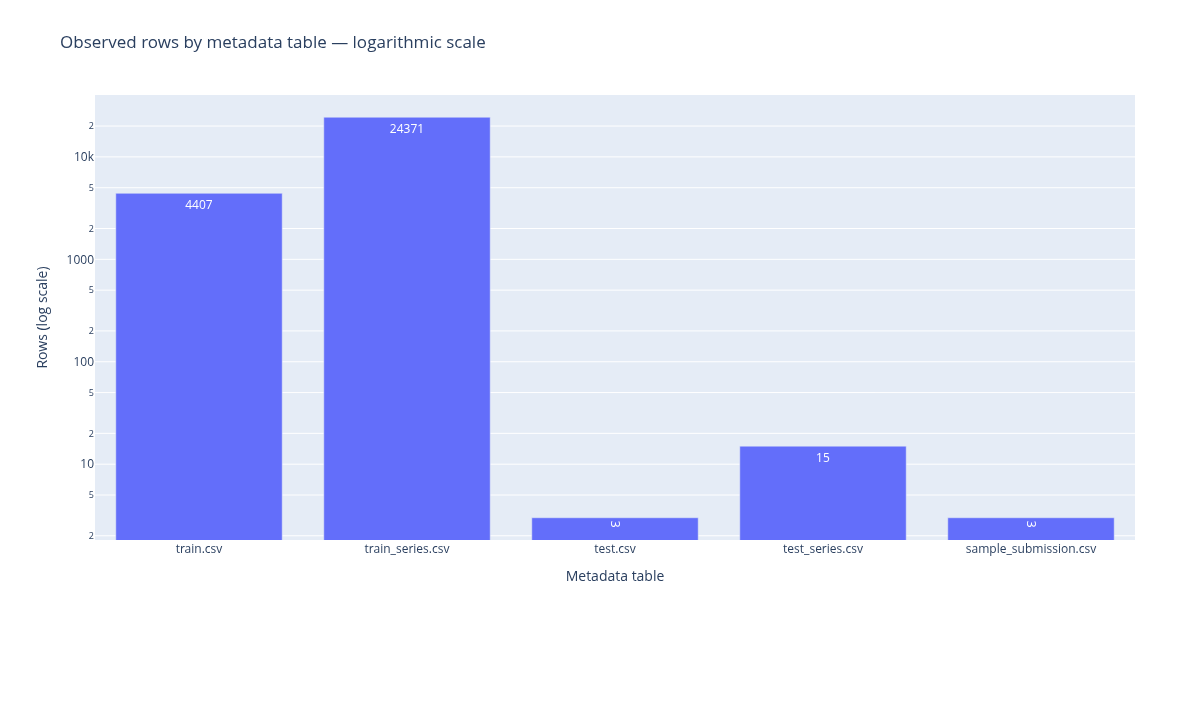

In [4]:
sizes = pd.read_csv(RUN / "table_sizes.csv")
fig = px.bar(sizes, x="table", y="rows", log_y=True, title="Observed rows by metadata table — logarithmic scale", text="rows")
fig.update_layout(xaxis_title="Metadata table", yaxis_title="Rows (log scale)", height=430)
fig.show(renderer="plotly_mimetype")


## 2 · Supervision availability, not disease prevalence
**Observed** means an explicit binary expert label is present. **Unknown** is kept missing. This plot never interprets an unmentioned finding as negative and does not reveal the positive/negative distribution of the scarce expert subset.


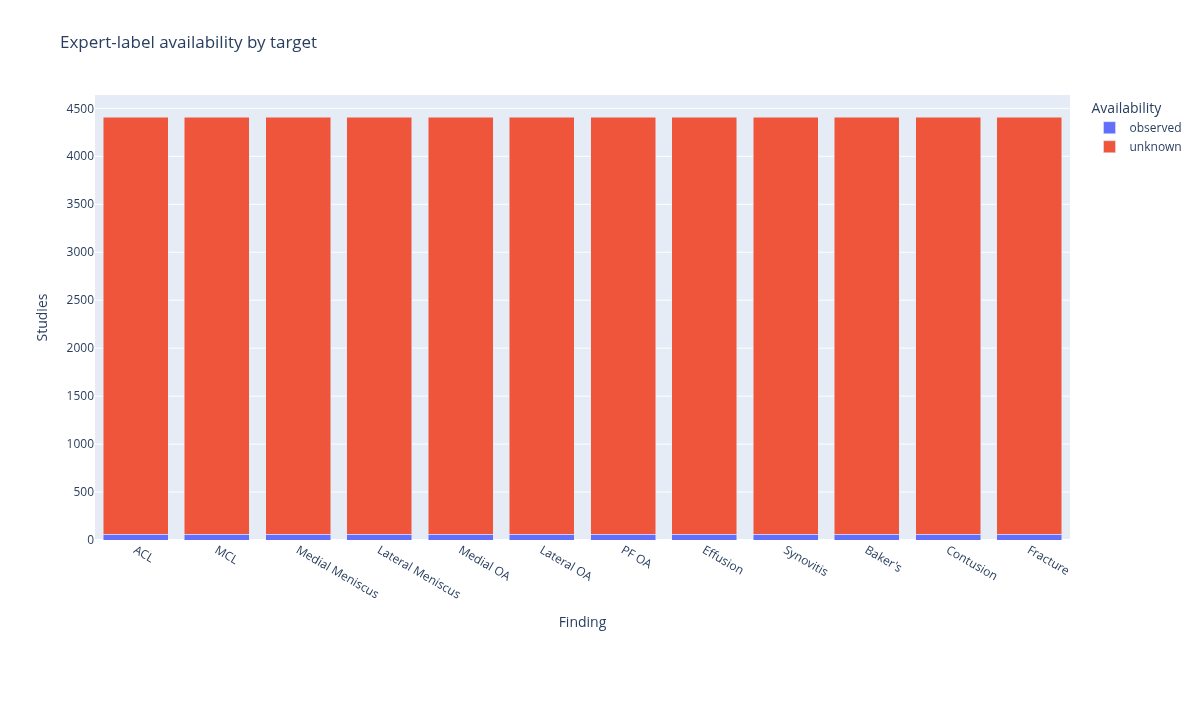

In [5]:
availability = pd.read_csv(RUN / "label_availability.csv")
long = availability.melt(id_vars="target", value_vars=["observed", "unknown"], var_name="label_state", value_name="studies")
fig = px.bar(long, x="target", y="studies", color="label_state", barmode="stack", title="Expert-label availability by target")
fig.update_layout(xaxis_title="Finding", yaxis_title="Studies", height=450, legend_title_text="Availability")
fig.show(renderer="plotly_mimetype")


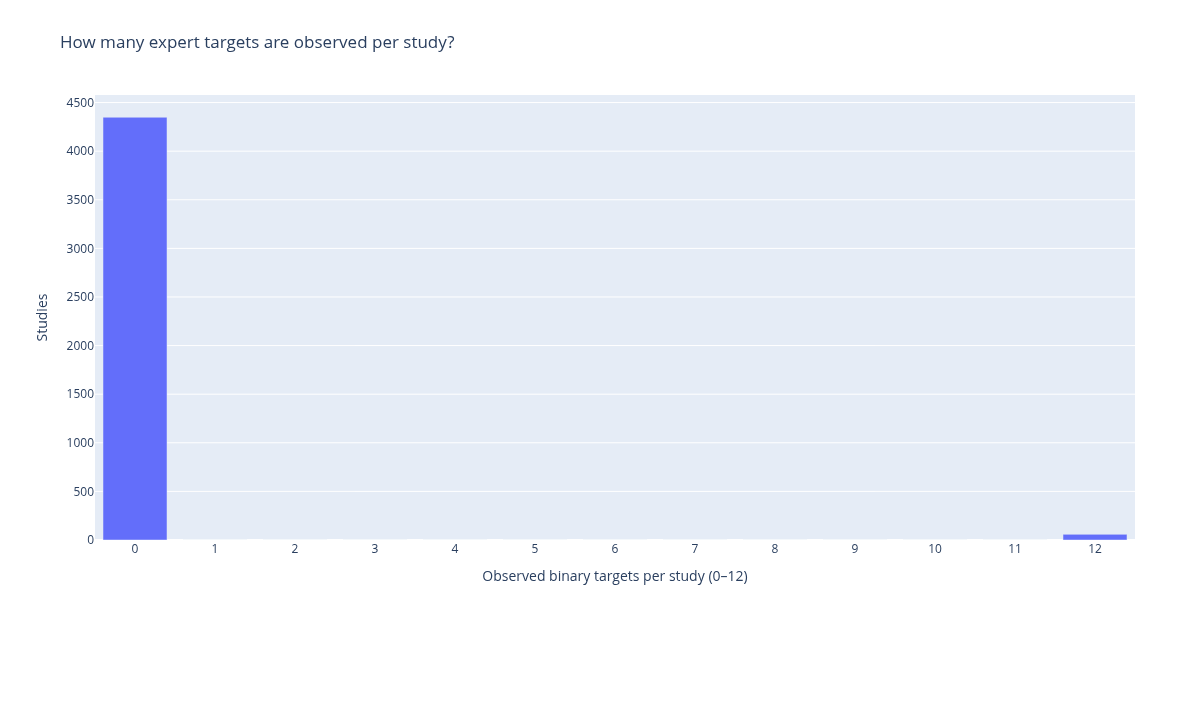

In [6]:
complete = pd.read_csv(RUN / "label_completeness.csv")
fig = px.bar(complete, x="observed_targets", y="studies", title="How many expert targets are observed per study?")
fig.update_xaxes(dtick=1, title="Observed binary targets per study (0–12)")
fig.update_yaxes(title="Studies")
fig.update_layout(height=390)
fig.show(renderer="plotly_mimetype")


## 3 · Report processing readiness
Report-length bins reveal processing requirements without exposing clinical text. Unicode-script presence indicates character-system coverage only: it is **not language identification**. A report may contain multiple scripts, so script counts can sum to more than the number of reports. Normalized duplicate text is a quality flag, not proof of shared patient identity.


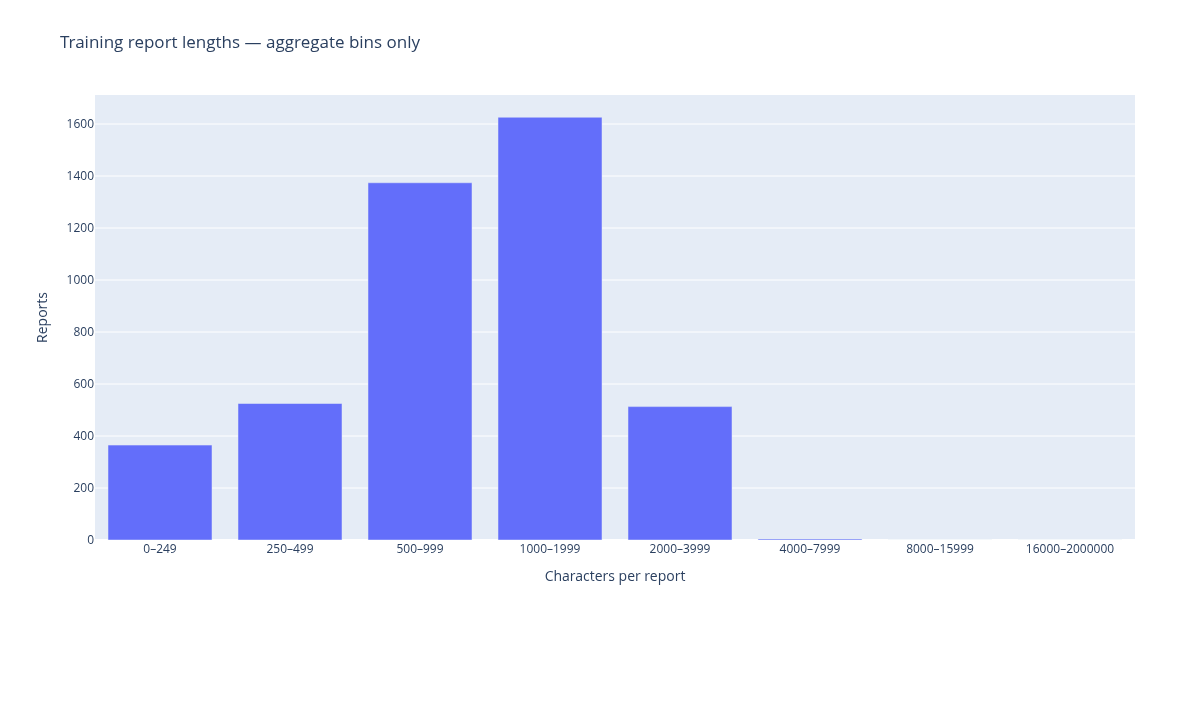

In [7]:
lengths = pd.read_csv(RUN / "report_length_histogram.csv")
fig = px.bar(lengths, x="character_range", y="reports", title="Training report lengths — aggregate bins only")
fig.update_layout(xaxis_title="Characters per report", yaxis_title="Reports", height=410)
fig.show(renderer="plotly_mimetype")


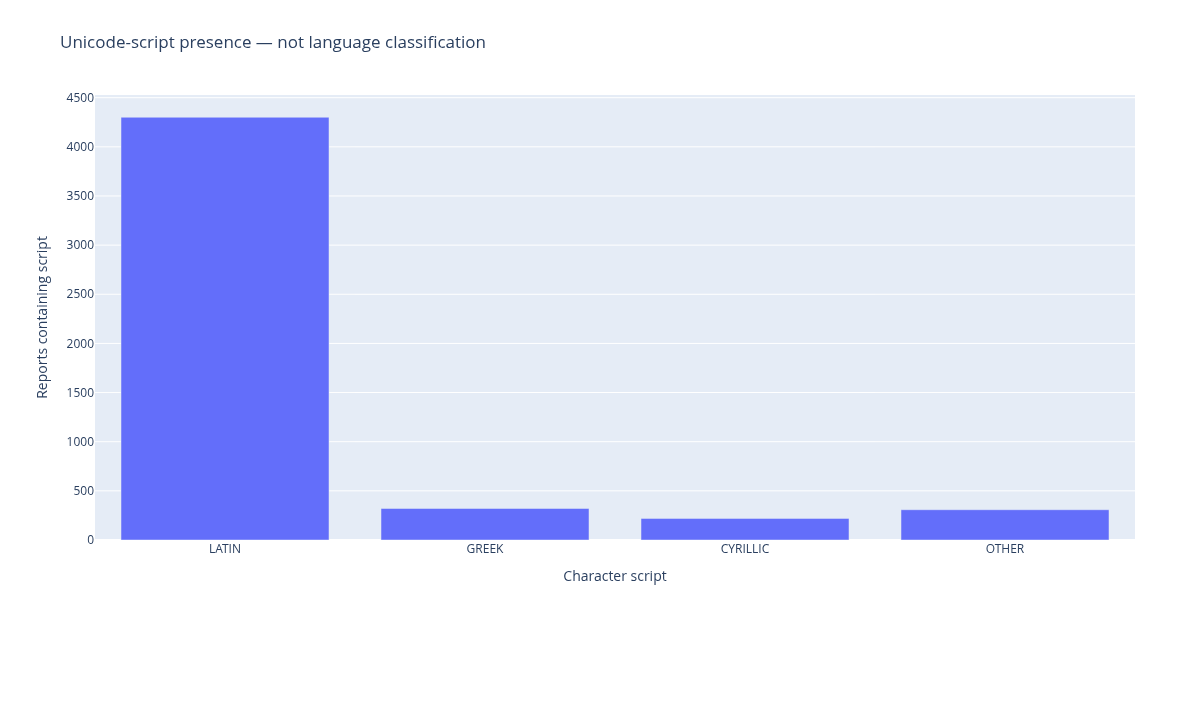

Reports in duplicate normalized-text groups: 204
Patient-level independence remains unverified.


In [8]:
scripts = pd.read_csv(RUN / "report_script_presence.csv")
fig = px.bar(scripts, x="script", y="reports_with_script", title="Unicode-script presence — not language classification")
fig.update_layout(xaxis_title="Character script", yaxis_title="Reports containing script", height=390)
fig.show(renderer="plotly_mimetype")
print("Reports in duplicate normalized-text groups:", SUPERVISION["reports_in_duplicate_groups"])
print("Patient-level independence remains unverified.")


## 4 · What image views can a representation use?
The next research rounds will compare image representations under fixed validation. Plane and contrast availability are prerequisites for designing those comparisons; counts alone do not demonstrate disease information or justify metadata shortcuts.


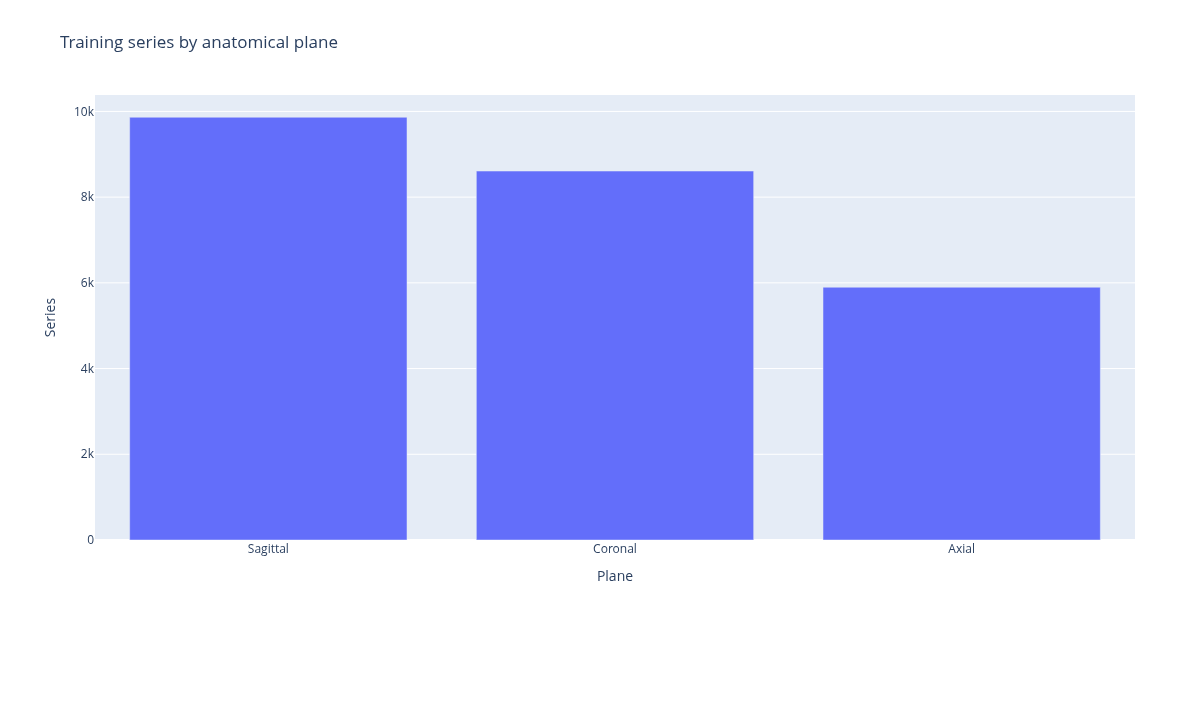

In [9]:
planes = pd.read_csv(RUN / "series_plane_counts.csv")
fig = px.bar(planes, x="plane", y="series", title="Training series by anatomical plane")
fig.update_layout(xaxis_title="Plane", yaxis_title="Series", height=380)
fig.show(renderer="plotly_mimetype")


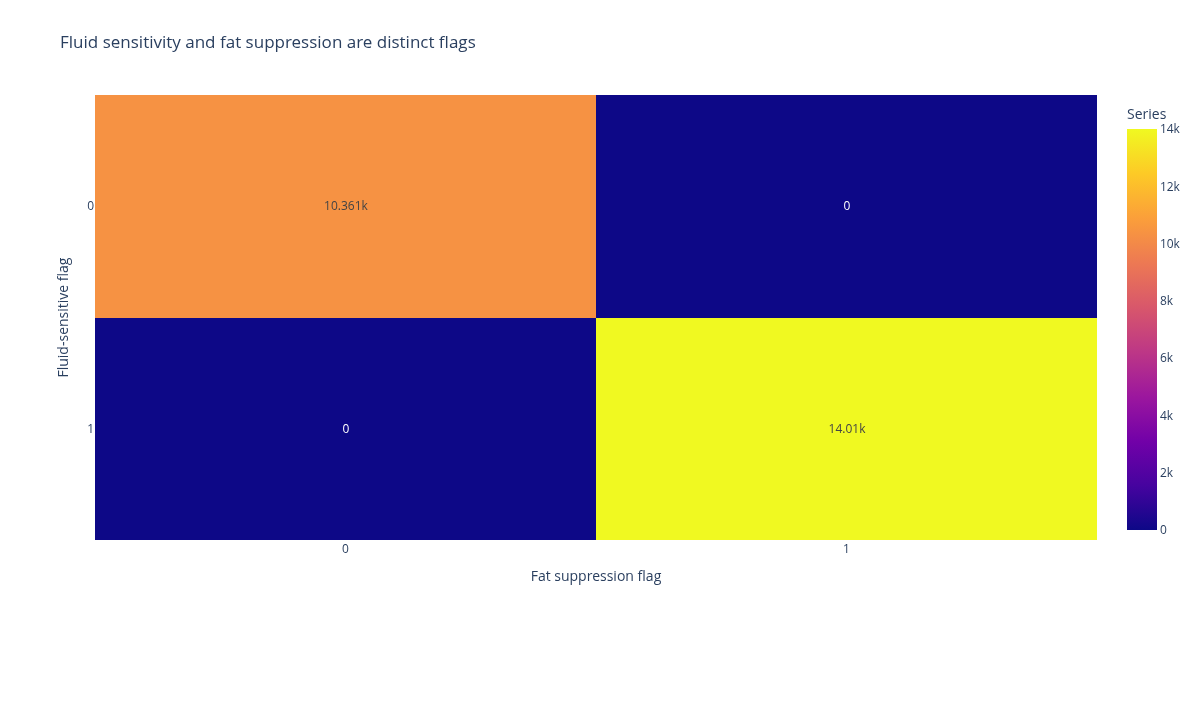

In [10]:
joint = pd.read_csv(RUN / "contrast_joint_counts.csv")
matrix = joint.pivot(index="Fluid_Sensitive", columns="Fat_Suppression", values="series")
fig = px.imshow(matrix, text_auto=True, aspect="auto", title="Fluid sensitivity and fat suppression are distinct flags",
    labels={"x": "Fat suppression flag", "y": "Fluid-sensitive flag", "color": "Series"})
fig.update_xaxes(tickmode="array", tickvals=[0,1], ticktext=["0", "1"])
fig.update_yaxes(tickmode="array", tickvals=[0,1], ticktext=["0", "1"])
fig.update_layout(height=410)
fig.show(renderer="plotly_mimetype")


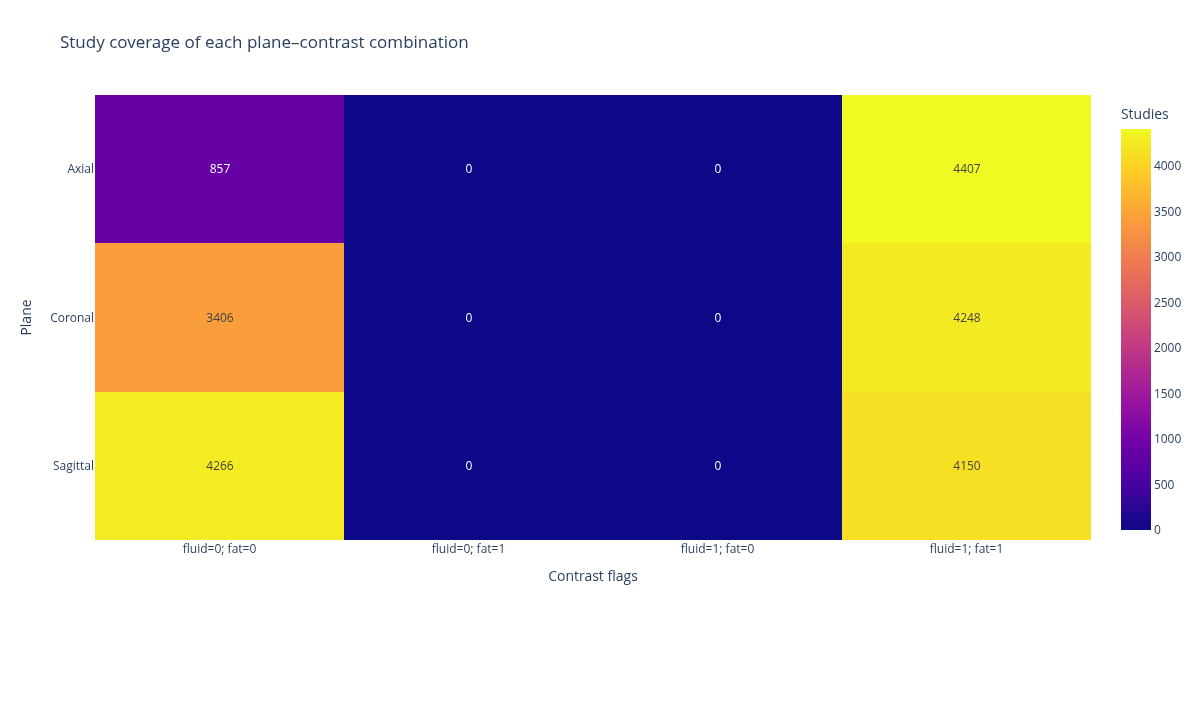

In [11]:
coverage = pd.read_csv(RUN / "plane_contrast_coverage.csv")
matrix = coverage.pivot(index="plane", columns="contrast", values="studies")
fig = px.imshow(matrix, text_auto=True, aspect="auto", title="Study coverage of each plane–contrast combination",
    labels={"x": "Contrast flags", "y": "Plane", "color": "Studies"})
fig.update_layout(height=440)
fig.show(renderer="plotly_mimetype")


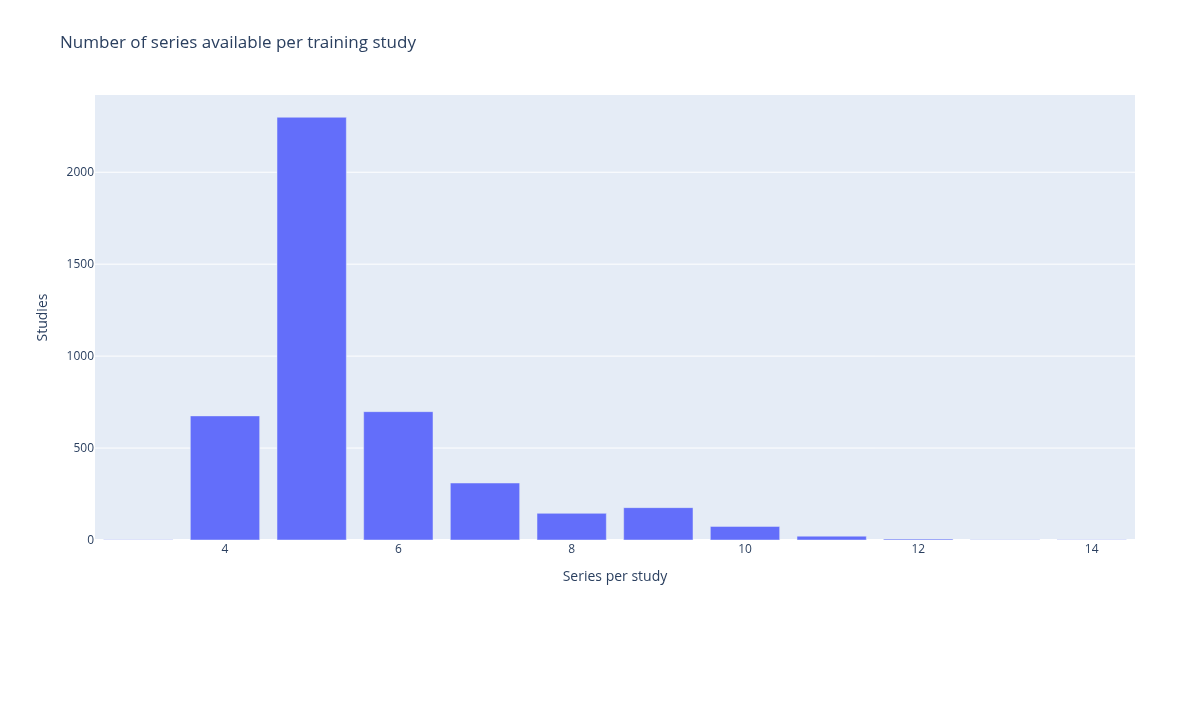

In [12]:
counts = pd.read_csv(RUN / "series_per_study.csv")
fig = px.bar(counts, x="series_per_study", y="studies", title="Number of series available per training study")
fig.update_layout(xaxis_title="Series per study", yaxis_title="Studies", height=390)
fig.show(renderer="plotly_mimetype")


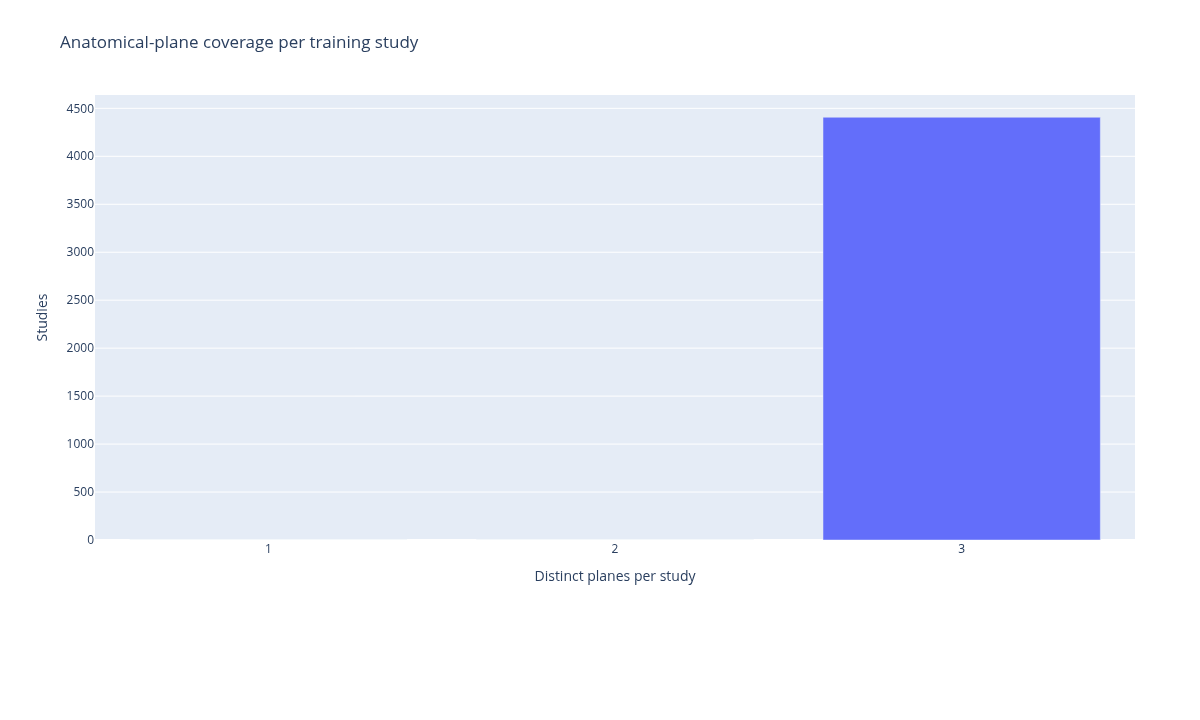

In [13]:
counts = pd.read_csv(RUN / "planes_per_study.csv")
fig = px.bar(counts, x="planes_available", y="studies", title="Anatomical-plane coverage per training study")
fig.update_xaxes(dtick=1, title="Distinct planes per study")
fig.update_yaxes(title="Studies")
fig.update_layout(height=390)
fig.show(renderer="plotly_mimetype")


## 5 · Implemented representation audit
The fixed acquisition module contains **65 candidate columns**: counts, presence indicators, proportions and a few coverage summaries. Related columns are intentionally redundant diagnostics. This is not a claim of 65 useful predictors. No supervised selection, encoder, ablation, or feature-based improvement has run.

These plots use training acquisition descriptors only. They are descriptive, not learned selection rules. Constant columns remain recorded; no column is promoted or rejected for predictive use here.


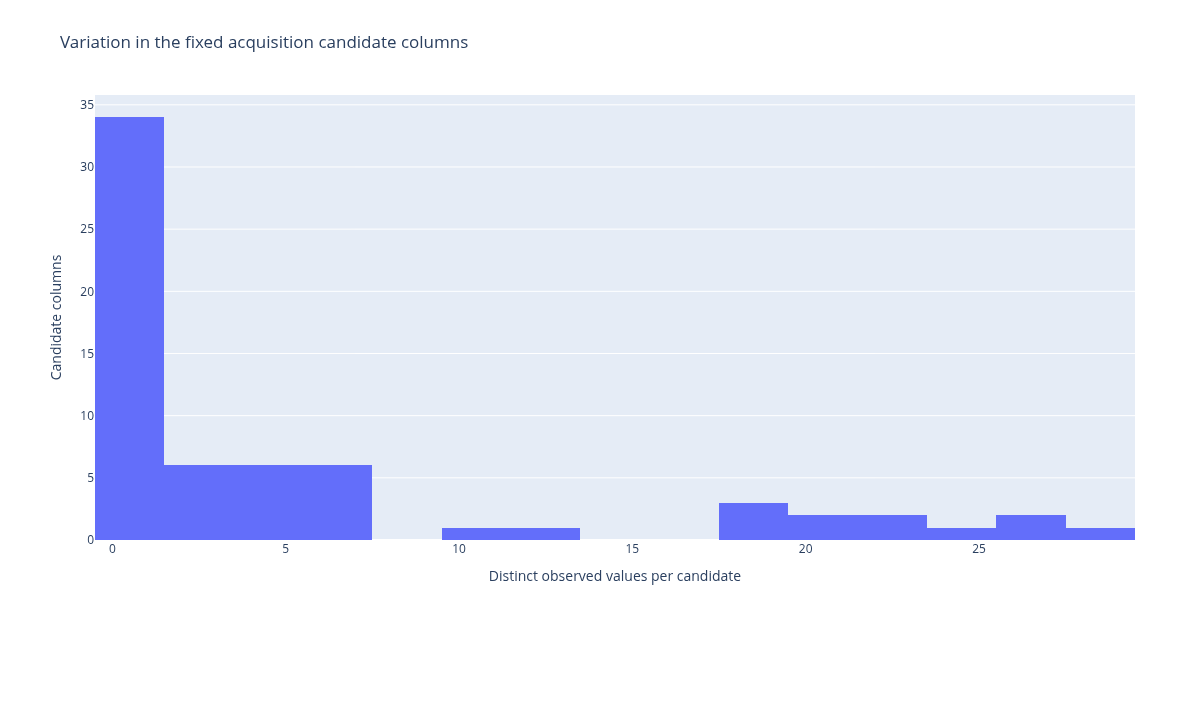

In [14]:
profile = pd.read_csv(RUN / "feature_profile.csv")
fig = px.histogram(profile, x="distinct_values", nbins=20, title="Variation in the fixed acquisition candidate columns")
fig.update_layout(xaxis_title="Distinct observed values per candidate", yaxis_title="Candidate columns", height=390)
fig.show(renderer="plotly_mimetype")


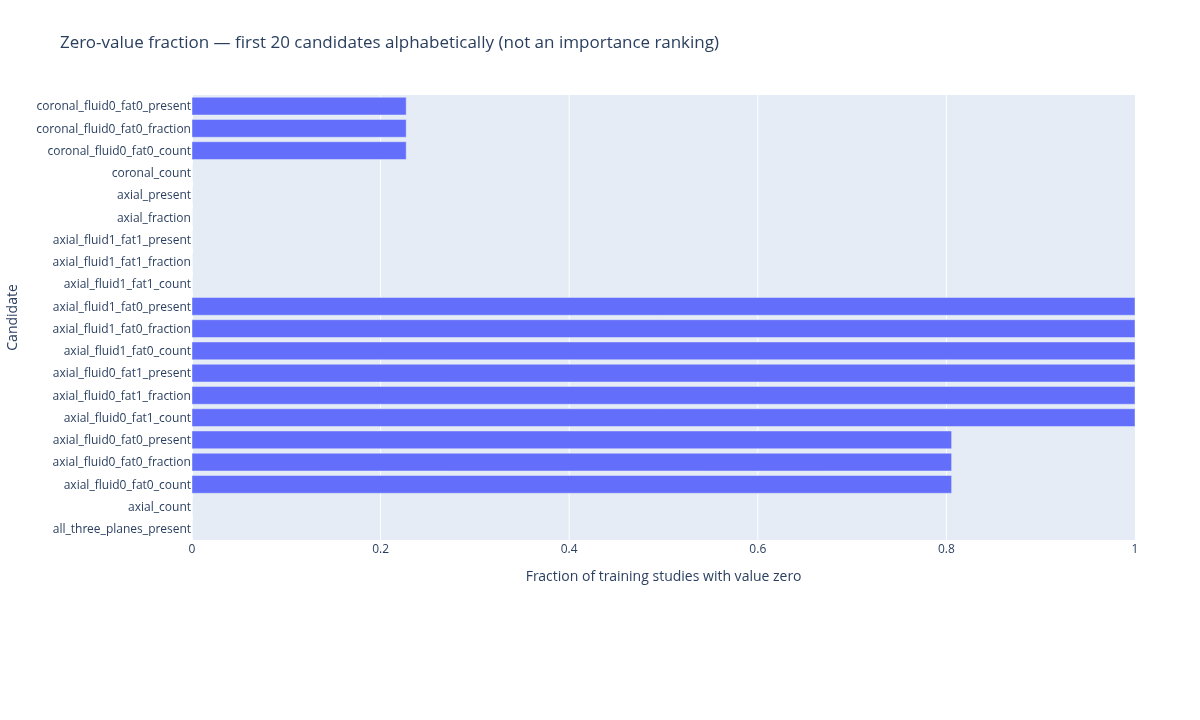

In [15]:
preview = profile.sort_values("feature").head(20)
fig = px.bar(preview, x="zero_fraction", y="feature", orientation="h",
    title="Zero-value fraction — first 20 candidates alphabetically (not an importance ranking)")
fig.update_layout(xaxis_title="Fraction of training studies with value zero", yaxis_title="Candidate", height=650)
fig.update_xaxes(range=[0,1])
fig.show(renderer="plotly_mimetype")


## 6 · Decision and stopping point

This milestone is accepted only when the schema and joins pass, unknown labels remain missing, input hashes are unchanged, the schema stage was reused after the controlled pause, tests match this source/environment, and all twelve figures display inline and survive save/reopen.

**Not established:** patient-disjoint validation; report-derived label quality; DICOM decoding correctness; predictive feature contribution; current leaderboard gap; model accuracy. The tiny example test is not suitable for estimating hidden-test prevalence or tuning features.

Next we will use these measured counts and coverage to define a defensible validation/supervision experiment, then a bounded selected-image audit. Do not proceed directly to a full image download, report-to-LLM transfer or GPU training.


In [16]:
assert SCHEMA["unknowns_kept_missing"] and SCHEMA["status"] == "PASS"
assert REPRESENTATION["train_test_schema_match"] and REPRESENTATION["model_fits"] == 0
assert not REPRESENTATION["uses_reports"] and not REPRESENTATION["uses_clinical_labels"]
assert REPRESENTATION["candidate_columns"] == 65
print("M01_METADATA_AUDIT_COMPLETE")
print("Predictive ablations: NOT RUN. Official AUC: NOT MEASURED. GitHub changes: NOT PERFORMED HERE.")
print("Save and reopen both notebooks. Then run: python scripts/pack_return.py")


M01_METADATA_AUDIT_COMPLETE
Predictive ablations: NOT RUN. Official AUC: NOT MEASURED. GitHub changes: NOT PERFORMED HERE.
Save and reopen both notebooks. Then run: python scripts/pack_return.py
